# Runtime analysis

In [1]:
# Libraries & paths

library(tidyverse)
library(yaml)
library(scales)
library(ggplot2)

BASE  <- "/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT"
BENCH <- file.path(BASE, "runtimes")

pub_samples <- readLines(file.path(BASE, "data/finished_samples.yml"))
pub_samples <- pub_samples[nchar(trimws(pub_samples)) > 0]

suppressMessages(source("../scripts/00_R_presets.R"))


Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
Warning message:
“package ‘purrr’ was built under R version 4.5.3”
Warning message:
“package ‘dplyr’ was built under R version 4.5.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Warning message in readLines(file.path(BASE, "data/finished_samples.yml")):
“incomplete final line foun

In [2]:
# Batch-read line 2 from a set of directories using a single awk call.
# NF-relative column indexing handles the "N days, H:M:S" h:m:s format correctly:
#   $1=seconds, $(NF-7)=max_rss, $(NF-1)=mean_load, $NF=cpu_time
batch_read_bench <- function(dirs) {
  dirs <- dirs[dir.exists(dirs)]
  if (length(dirs) == 0) return(tibble())
  cmd <- paste(
    "find", paste(shQuote(dirs), collapse = " "),
    "-name '*.txt'",
    "-exec awk 'FNR==2{print FILENAME\"\\t\"$1\"\\t\"$(NF-7)\"\\t\"$(NF-1)\"\\t\"$NF}' {} +"
  )
  lines <- system(cmd, intern = TRUE)
  if (length(lines) == 0) return(tibble())
  read_tsv(
    I(paste(lines, collapse = "\n")),
    col_names = c("path", "seconds", "max_rss", "mean_load", "cpu_time"),
    col_types = "cdddd"
  )
}

In [3]:
# Build flowcell_id → (sample, read_type) lookup for dorado/herro files
# whose names don't directly encode the T2T sample ID
datasets <- yaml.load_file(file.path(BASE, "data/datasets.yml"))

fc_map <- imap_dfr(datasets, function(data, sample) {
  if (!is.list(data)) return(NULL)
  imap_dfr(data, function(paths, read_type) {
    if (is.null(paths)) return(NULL)
    if (!is.list(paths)) paths <- list(paths)
    map_dfr(paths, function(p) {
      fc <- basename(p)
      # Extract flowcell prefix: 24070LRaXXX or 25006LRaXXX with optional run ID
      m <- regmatches(fc, regexpr("(?:24070|25006)LRa\\d+(?:[_-]?\\d+)?", fc))
      if (length(m) == 0) return(NULL)
      tibble(fc_prefix = sub("[_-]\\d+$", "", m), sample = sample, read_type = read_type)
    })
  })
}) %>%
  filter(sample %in% pub_samples) %>%
  distinct(fc_prefix, sample, .keep_all = TRUE)

# Extract sample from a benchmark filename:
# (1) direct T2T label in filename, (2) datasets.yml lookup, (3) NA
extract_sample <- function(fname) {
  # Direct match: T2T00, T2T01, T2T00_1, T2T_HG002 etc.
  m <- regmatches(fname, regexpr("T2T(?:_HG002|\\d+(?:[_-][12])?)", fname, perl = TRUE))
  if (length(m) > 0) {
    s <- gsub("-", "_", m)
    return(if (s %in% pub_samples) s else NA_character_)
  }
  # Flowcell prefix lookup
  fc <- regmatches(fname, regexpr("(?:24070|25006)LRa\\d+", fname, perl = TRUE))
  if (length(fc) > 0) {
    hit <- fc_map$sample[fc_map$fc_prefix == fc]
    if (length(hit) > 0) return(hit[1])
  }
  NA_character_
}

In [4]:
dip3d_dirs <- file.path(BENCH, c(
  "dip3d/dip3d_map_reads", "dip3d/dip3d_split_bams",
  "dip3d/dip3d_select_chr_snp_bam", "dip3d/dip3d_calculate_coverage",
  "dip3d/dip3d_filter_vcf_by_coverage", "dip3d/whatshap_phase_vcf",
  "dip3d/dip3d_bam_haplotag", "dip3d/dip3d_run_ashic",
  "dip3d/dip3d_ashic_pack", "dip3d/dip3d_ashic_binning",
  "dip3d/dip3d_ashic_split2chrs", "dip3d/dip3d_frag_to_ashic_read_pair",
  "dip3d/all_merge_dip3d"
))

all_dirs <- c(
  file.path(BENCH, c(
    "dorado/sup", "dorado/apk",
    "dorado_summary",
    "dorado_correct_inference", "dorado_correct_mapping", "dorado_trim",
    "porec_qc", "create_PE_from_PoreC", "yak_count",
    "verkko", "verkko_scaffold",
    "repeatmasker", "cenmap_single",
    "patmat"
  )),
  dip3d_dirs
)

# Single awk pass over all ~5000 files
raw <- batch_read_bench(all_dirs)

# Add root-level medaka_polishing files (not in a subdir)
medaka_files <- list.files(BENCH, pattern = "\\.medaka_polishing\\.txt$",
                           full.names = TRUE, recursive = FALSE)
if (length(medaka_files) > 0) {
  medaka_lines <- system(
    paste("awk 'FNR==2{print FILENAME\"\\t\"$1\"\\t\"$(NF-7)\"\\t\"$(NF-1)\"\\t\"$NF}'",
          paste(shQuote(medaka_files), collapse = " ")),
    intern = TRUE
  )
  raw <- bind_rows(raw,
    read_tsv(I(paste(medaka_lines, collapse = "\n")),
             col_names = c("path","seconds","max_rss","mean_load","cpu_time"),
             col_types = "cdddd"))
}

# Assign step label from file path
raw <- raw %>%
  mutate(step = case_when(
    str_detect(path, "/dorado/sup/|/dorado/apk/")      ~ "SUP Basecalling",
    str_detect(path, "/dorado_summary/")                ~ "Basecalling summary",
    str_detect(path, "/dorado_correct_inference/")      ~ "Herro inference",
    str_detect(path, "/dorado_correct_mapping/")        ~ "Herro mapping",
    str_detect(path, "/dorado_trim/")                   ~ "Herro trim",
    str_detect(path, "/porec_qc/")                      ~ "wf-human-variation",
    str_detect(path, "/create_PE_from_PoreC/")          ~ "PoreC PE creation",
    str_detect(path, "/verkko/") &
      !str_detect(path, "/verkko_scaffold/")            ~ "Verkko Assembly",
    str_detect(path, "/verkko_scaffold/")               ~ "Verkko Scaffolding",
    str_detect(path, "\\.medaka_polishing\\.txt$")      ~ "Medaka polishing",
    str_detect(path, "/repeatmasker/")                  ~ "RepeatMasker",
    str_detect(path, "/cenmap_single/")                 ~ "CenMap",
    str_detect(path, "/dip3d/")                         ~ "Dip3D",
    str_detect(path, "/patmat/")                       ~ "PatMat",
    TRUE                                                ~ NA_character_
  )) %>%
  # CenMap sample is the subdirectory name; others use filename
  mutate(sample = if_else(
    str_detect(path, "/cenmap_single/"),
    basename(dirname(path)),
    map_chr(basename(path), extract_sample)
  )) %>%
  filter(!is.na(step), !is.na(sample), sample %in% pub_samples) %>%
  filter(seconds > 300)

# Note: mapping.smk and methylation.smk have no benchmark: directives — no data available.

cat("Benchmark rows (>5 min, pub samples):", nrow(raw), "\n")
count(raw, step) %>% arrange(desc(n)) %>% print(n = 30)

Benchmark rows (>5 min, pub samples): 1804 
# A tibble: 14 × 2
   step                    n
   <chr>               <int>
 1 Dip3D                1244
 2 SUP Basecalling       105
 3 Basecalling summary   101
 4 Herro mapping          65
 5 Herro trim             63
 6 Herro inference        56
 7 wf-human-variation     48
 8 PatMat                 24
 9 RepeatMasker           24
10 CenMap                 23
11 Verkko Assembly        22
12 Verkko Scaffolding     22
13 Medaka polishing        5
14 PoreC PE creation       2


In [5]:
step_order <- c(
  "SUP Basecalling", "Basecalling summary",
  "Herro inference", "Herro mapping", "Herro trim",
   
  "Verkko Assembly", "Verkko Scaffolding", 
  "wf-human-variation", "RepeatMasker", "CenMap", "Dip3D", "PatMat"
)

# Sum across all flowcells / chromosomes per sample x step
agg <- raw %>%
  group_by(sample, step) %>%
  summarise(
    hours      = sum(seconds) / 3600,
    cpu_hours  = sum(cpu_time) / 3600,
    max_ram_gb = max(max_rss) / 1024,
    eff_cores  = mean(mean_load / 100, na.rm = TRUE),
    .groups    = "drop"
  ) %>%
  mutate(
    sample_display = factor(sample, levels = pub_samples),
    step           = factor(step,   levels = step_order)
  )

# Remove low-end outliers for Assembly and Scaffolding:
# samples whose total runtime falls below Q1 - 1.5*IQR most likely
# did not run the full pipeline (e.g. T2T00_2 scaffold finished in 13 s)
assembly_steps <- c("Verkko Assembly", "Verkko Scaffolding")

iqr_bounds <- agg %>%
  filter(step %in% assembly_steps) %>%
  group_by(step) %>%
  summarise(lo = quantile(hours, 0.25) - 1.5 * IQR(hours), .groups = "drop")

agg <- agg %>%
  left_join(iqr_bounds, by = "step") %>%
  filter(is.na(lo) | hours >= lo) %>%
  select(-lo)

cat("Aggregated rows after outlier removal:", nrow(agg), "\n")
agg %>% filter(step %in% assembly_steps) %>%
  count(step) %>% print()

Aggregated rows after outlier removal: 275 


# A tibble: 2 × 2
  step                   n
  <fct>              <int>
1 Verkko Assembly       18
2 Verkko Scaffolding    21


In [6]:
resource_meta <- tribble(
  ~step,                  ~threads, ~gpus, ~category,
  "SUP Basecalling",               2,     2,   "Preprocessing",
  "Basecalling summary",       4,     0,   "Preprocessing",
  "Herro inference",           1,     1,   "Preprocessing",
  "Herro mapping",            20,     0,   "Preprocessing",
  "Herro trim",               20,     0,   "Preprocessing",
  "Verkko Assembly",        48,     0,   "Assembly",
  "Verkko Scaffolding",              72,     0,   "Assembly",
  "wf-human-variation",       36,     0,   "Downstream",
  "RepeatMasker",             32,     0,   "Downstream",
  "CenMap",                    1,     0,   "Downstream",
  "Dip3D",                     8,     0,   "Downstream",  # median across sub-steps
  "PatMat",                    8,     0,   "Downstream",
) %>%
  mutate(
    step     = factor(step,     levels = step_order),
    category = factor(category, levels = c("Preprocessing", "Assembly", "Downstream"))
  )

agg <- agg %>%
  left_join(resource_meta, by = "step") %>%
  mutate(
    cpu_hours_allocated = hours * threads,
    gpu_hours           = if_else(gpus > 0, hours * gpus, 0),
    cpu_hours_effective = hours * eff_cores,
    gpu_step            = gpus > 0
  )

category_colours <- c(
  "Preprocessing" = "#4393C3",
  "Assembly"      = "#D6604D",
  "Downstream"    = "#74C476"
)

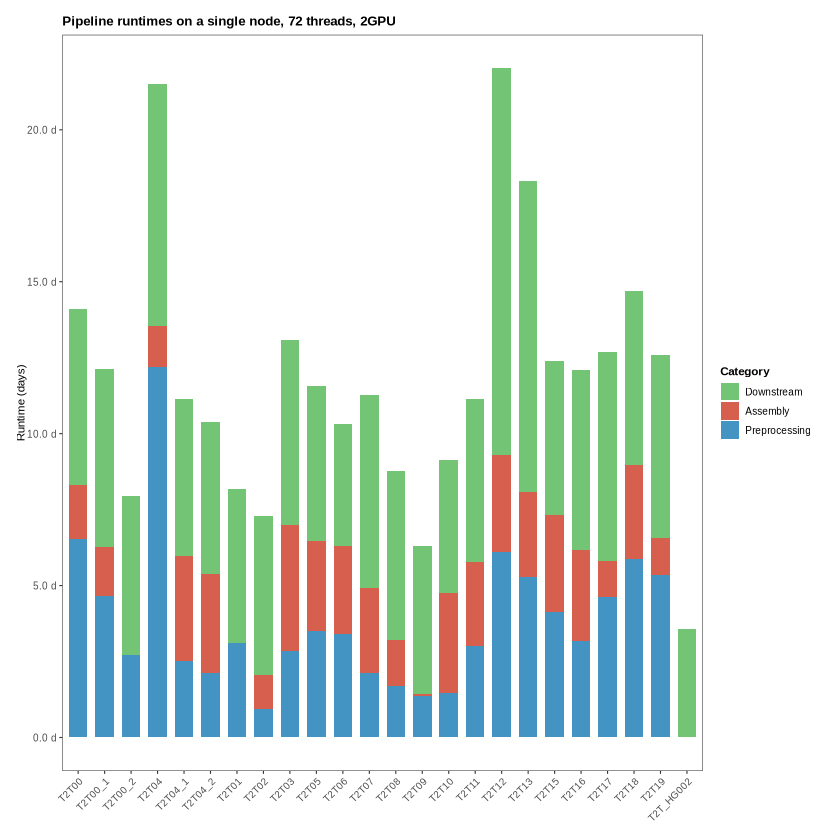

In [29]:
# Stacked bar: total runtime per sample coloured by category
p_cat <- agg %>%
  filter(!is.na(category)) %>%
  group_by(sample_display, category) %>%
  summarise(days = sum(hours, na.rm = TRUE) / 24, .groups = "drop") %>%
  mutate(category = factor(category, levels = c("Downstream", "Assembly", "Preprocessing"))) %>%
  ggplot(aes(x = sample_display, y = days, fill = category)) +
  geom_col(width = 0.7) +
  scale_fill_manual(values = category_colours) +
  scale_y_continuous(labels = label_number(suffix = " d", accuracy = 0.1)) +
  labs(title = "Pipeline runtimes on a single node, 72 threads, 2GPU",
       x = NULL, y = "Runtime (days)", fill = "Category") +
  t2t_theme(base_size = 7) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

ggsave("../../doc/figures/runtime_p_cat.pdf", p_cat, width = 7, height = 3)
ggsave("../../doc/figures/runtime_p_cat.png", p_cat, width = 7, height = 3, dpi = 300)
p_cat

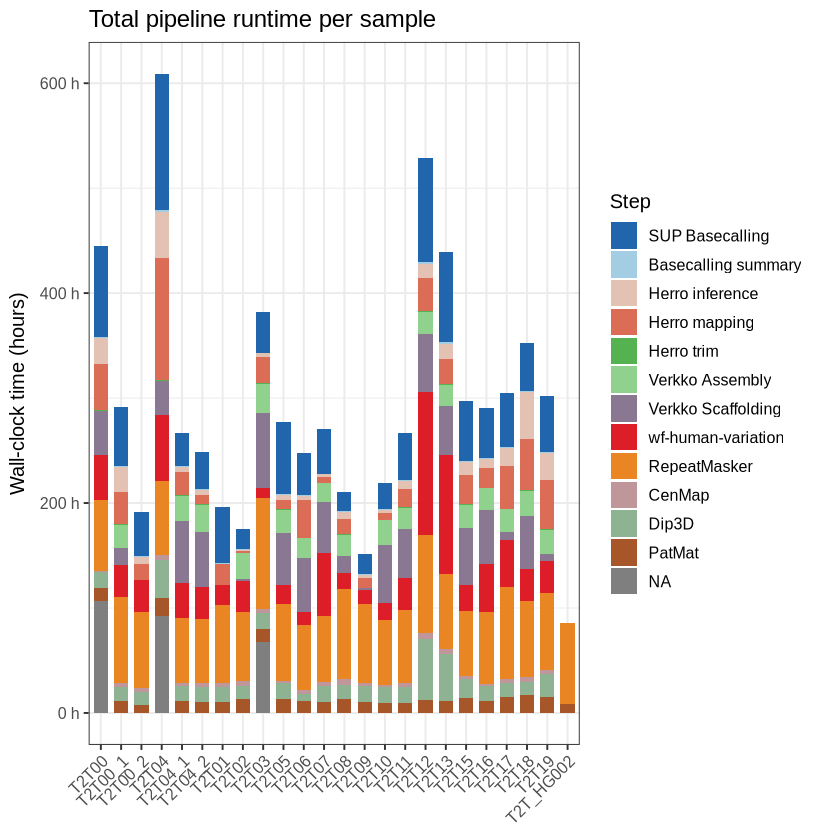

In [8]:
# Stacked bar: per sample coloured by individual step
step_colours <- setNames(
  colorRampPalette(c(
    "#2166AC","#92C5DE","#D1E5F0",
    "#F4A582","#D6604D",
    "#4DAF4A","#A1D99B","#74C476",
    "#984EA3","#E41A1C","#FF7F00",
    "#8DA0CB","#FC8D62","#66C2A5","#A65628"
  ))(length(step_order)),
  step_order
)

p_stack <- ggplot(agg, aes(x = sample_display, y = hours, fill = step)) +
  geom_col(width = 0.7) +
  scale_fill_manual(values = step_colours, name = "Step") +
  scale_y_continuous(labels = label_comma(suffix = " h")) +
  labs(title = "Total pipeline runtime per sample",
       x = NULL, y = "Wall-clock time (hours)") +
  theme_bw(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "right")
p_stack

Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Bars: allocated threads (dark) / GPUs (light).  Dots: actual effective CPU cores per sample, centred on CPU bar.  ▲: GPU-accelerated step.' in 'mbcsToSbcs': for ▲ (U+25B2)”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 16 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


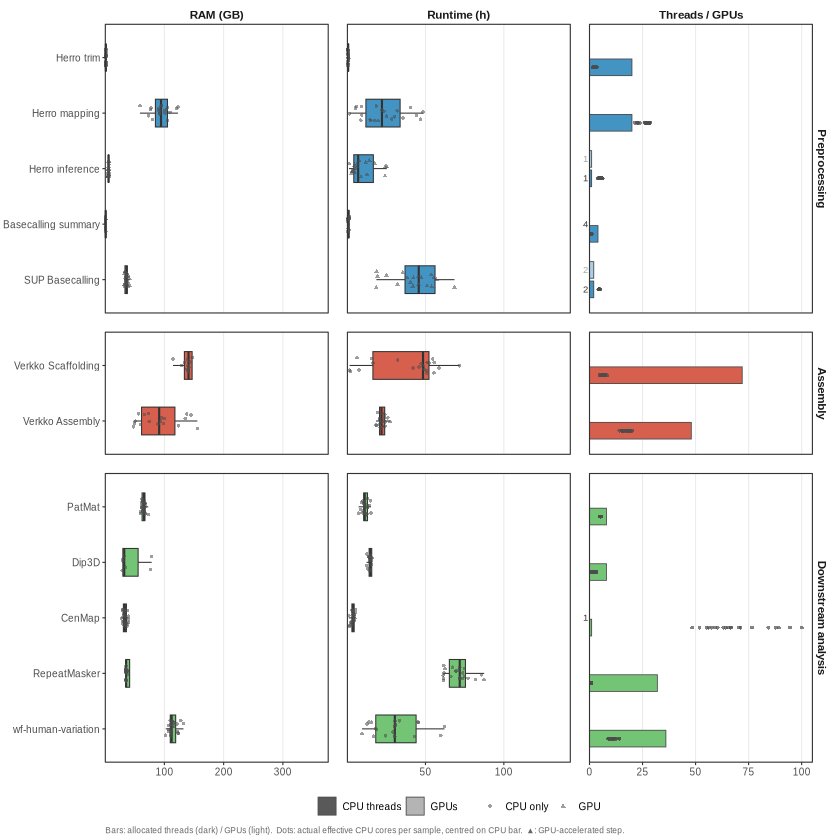

In [ ]:
# ── Combined figure: RAM | Runtime | Threads+GPUs, rows = pipeline phase ─────

panel_levels <- c("RAM (GB)", "Runtime (h)", "Threads / GPUs")
cat_levels   <- c("Preprocessing", "Assembly", "Downstream analysis")
cat_cols     <- c(
  Preprocessing         = "#4393C3",
  Assembly              = "#D6604D",
  `Downstream analysis` = "#74C476"
)

relabel_cat <- function(x) {
  factor(
    if_else(as.character(x) == "Downstream", "Downstream analysis", as.character(x)),
    levels = cat_levels
  )
}

# Boxplot panels (RAM + Runtime): drop rows where step/category is NA
agg_long <- agg |>
  mutate(category = relabel_cat(category)) |>
  filter(!is.na(step), !is.na(category)) |>
  select(step, category, gpu_step, max_ram_gb, hours) |>
  pivot_longer(c(max_ram_gb, hours),
               names_to  = "panel",
               values_to = "value") |>
  mutate(panel = factor(
    if_else(panel == "max_ram_gb", "RAM (GB)", "Runtime (h)"),
    levels = panel_levels
  ))

# Jitter: clip to boxplot whisker range per step×panel
whisker_bounds <- agg_long |>
  group_by(step, panel) |>
  summarise(
    lo = quantile(value, 0.25, na.rm = TRUE) - 1.5 * IQR(value, na.rm = TRUE),
    hi = quantile(value, 0.75, na.rm = TRUE) + 1.5 * IQR(value, na.rm = TRUE),
    .groups = "drop"
  )

agg_jitter <- agg_long |>
  left_join(whisker_bounds, by = c("step", "panel")) |>
  filter(value >= lo & value <= hi) |>
  select(-lo, -hi)

# Bar panel: allocated threads + GPUs (cap at 100)
resource_long <- resource_meta |>
  mutate(category = relabel_cat(category)) |>
  select(step, category, threads, gpus) |>
  pivot_longer(c(threads, gpus),
               names_to  = "resource",
               values_to = "count") |>
  mutate(
    resource = factor(
      if_else(resource == "threads", "CPU threads", "GPUs"),
      levels = c("CPU threads", "GPUs")
    ),
    count = pmin(count, 100L),
    panel = factor("Threads / GPUs", levels = panel_levels)
  )

# Effective CPU cores swarm: clip outliers (IQR rule), cap at 100.
# Add phantom GPU rows (eff_cores = NA) so position_jitterdodge sees 2 groups
# and offsets CPU threads points onto the CPU bar (group 1 → -0.175 in local coords).
util_long <- agg |>
  mutate(category = relabel_cat(category)) |>
  filter(!is.na(eff_cores), !is.na(step), !is.na(category)) |>
  select(step, category, eff_cores) |>
  group_by(step) |>
  filter(
    eff_cores >= quantile(eff_cores, 0.25) - 1.5 * IQR(eff_cores),
    eff_cores <= quantile(eff_cores, 0.75) + 1.5 * IQR(eff_cores)
  ) |>
  ungroup() |>
  mutate(
    eff_cores = pmin(eff_cores, 100),
    resource  = factor("CPU threads", levels = c("CPU threads", "GPUs")),
    panel     = factor("Threads / GPUs", levels = panel_levels)
  )

util_phantom <- util_long |>
  distinct(step, category, panel) |>
  mutate(eff_cores = NA_real_,
         resource  = factor("GPUs", levels = c("CPU threads", "GPUs")))

util_dodgeable <- bind_rows(util_long, util_phantom)

p_combined <- ggplot() +
  # RAM + Runtime: boxplots (full data for correct quartiles)
  geom_boxplot(
    data    = agg_long,
    mapping = aes(y = step, x = value, fill = category),
    outlier.shape = NA, width = 0.5, linewidth = 0.3
  ) +
  # RAM + Runtime: per-sample jitter (within whiskers only)
  geom_jitter(
    data    = agg_jitter,
    mapping = aes(y = step, x = value, shape = gpu_step),
    height  = 0.15, size = 0.8, alpha = 0.55, colour = "grey30"
  ) +
  # Threads / GPUs: allocated resource bars with outline
  geom_col(
    data    = resource_long,
    mapping = aes(y = step, x = count, fill = category, alpha = resource),
    position = position_dodge(width = 0.7), width = 0.6,
    colour = "grey30", linewidth = 0.25
  ) +
  # Threads / GPUs: count labels for small values, placed left of x = 0 (clip = "off")
  geom_text(
    data    = resource_long |> filter(count > 0, count < 5),
    mapping = aes(y = step, x = 0, label = count, alpha = resource),
    position    = position_dodge(width = 0.7),
    hjust = 1.3, size = 2, colour = "grey20", show.legend = FALSE
  ) +
  # Threads / GPUs: actual effective CPU cores, centred on the CPU threads bar.
  # Phantom GPU rows (eff_cores = NA) tell jitterdodge there are 2 groups so
  # "CPU threads" (group 1) is offset to the correct dodged position.
  geom_point(
    data    = util_dodgeable,
    mapping = aes(y = step, x = eff_cores, group = resource),
    position = position_jitterdodge(
      dodge.width  = 0.7,
      jitter.height = 0.1,
      jitter.width  = 0,
      seed = 42
    ),
    size = 0.9, alpha = 0.7, colour = "grey30", shape = 16,
    na.rm = TRUE
  ) +
  scale_fill_manual(values = cat_cols, guide = "none") +
  scale_alpha_manual(values = c(`CPU threads` = 1, GPUs = 0.45), name = NULL) +
  scale_shape_manual(values = c(`FALSE` = 16, `TRUE` = 17),
                     labels = c("CPU only", "GPU"), name = NULL) +
  scale_x_continuous(labels = label_number(),
                     expand  = expansion(mult = c(0, 0.05))) +
  coord_cartesian(clip = "off") +
  facet_grid(category ~ panel, scales = "free", space = "free_y") +
  labs(x = NULL, y = NULL) +
  t2t_theme(base_size = 7) +
  theme(
    strip.text.x       = element_text(face = "bold", size = 7),
    strip.text.y       = element_text(face = "bold", size = 7),
    legend.position    = "bottom",
    panel.grid.major.x = element_line(colour = "grey92", linewidth = 0.3),
    panel.spacing      = unit(0.8, "lines"),
    plot.margin        = margin(3, 5, 3, 3, "pt"),
    plot.caption       = element_text(size = 5, colour = "grey40", hjust = 0)
  )

ggsave("../../doc/figures/runtime_combined.pdf", p_combined, width = 7.5, height = 6)
ggsave("../../doc/figures/runtime_combined.png", p_combined, width = 7.5, height = 6, dpi = 300)
p_combined


In [15]:
# Summary table
agg %>%
  group_by(category, step, threads, gpus) %>%
  summarise(
    n_samples       = n(),
    median_h        = median(hours)      %>% round(1),
    max_h           = max(hours)         %>% round(1),
    total_h         = sum(hours)         %>% round(0),
    total_gpu_h     = sum(gpu_hours)     %>% round(0),
    total_cpu_eff_h = sum(cpu_hours_effective, na.rm = TRUE) %>% round(0),
    median_ram_gb   = median(max_ram_gb) %>% round(1),
    .groups = "drop"
  ) %>%
  mutate(compute = if_else(gpus > 0,
    paste0(gpus, " GPU"), paste0(threads, " CPU threads"))) %>%
  select(category, step, compute, n_samples,
         median_h, max_h, total_h, total_gpu_h, total_cpu_eff_h, median_ram_gb) %>%
  arrange(category, desc(total_h)) %>%
  print(n = 30)

# A tibble: 13 × 10
   category      step       compute n_samples median_h max_h total_h total_gpu_h
   <fct>         <fct>      <chr>       <int>    <dbl> <dbl>   <dbl>       <dbl>
 1 Preprocessing SUP Basec… 2 GPU          23     45.7 130.     1193        2386
 2 Preprocessing Herro map… 20 CPU…        23     22.2 116.      618           0
 3 Preprocessing Herro inf… 1 GPU          22      7    44.6     281         281
 4 Preprocessing Basecalli… 4 CPU …        23      0.9   2.2      22           0
 5 Preprocessing Herro trim 20 CPU…        23      0.7   1.5      16           0
 6 Assembly      Verkko Sc… 72 CPU…        21     48.4  71.7     815           0
 7 Assembly      Verkko As… 48 CPU…        18     21.9  27.4     400           0
 8 Downstream    RepeatMas… 32 CPU…        24     71.8 106.     1759           0
 9 Downstream    wf-human-… 36 CPU…        23     30.4 136.      880           0
10 Downstream    Dip3D      8 CPU …        23     14.8  57.6     430           0
11 Downs